In [20]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.stochastic_sir import generate_dataset
from src.ml_model import train_model, evaluate

In [22]:
generate_dataset()

data = np.load("../results/stochastic_dataset.npz")

t = data["t"]
S = data["S"]
I = data["I"]
R = data["R"]

print("Dataset shape")
print("S:", S.shape)
print("I:", I.shape)
print("R:", R.shape)

Dataset saved: results/stochastic_dataset.npz
Dataset shape
S: (16, 160)
I: (16, 160)
R: (16, 160)


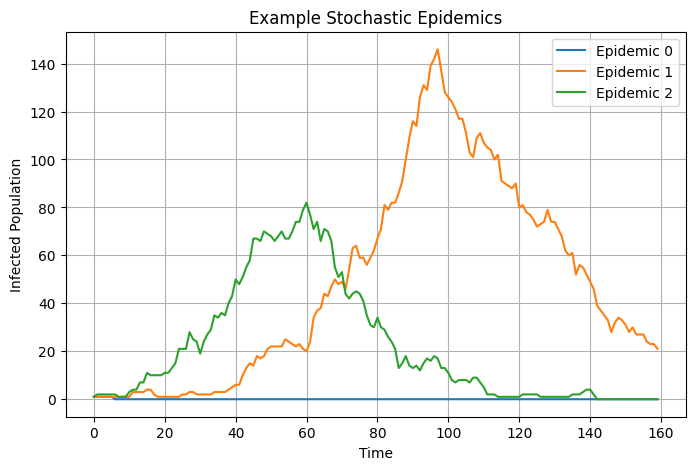

In [23]:
plt.figure(figsize=(8,5))

for i in range(3):
    plt.plot(t, I[i], label=f"Epidemic {i}")

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("Example Stochastic Epidemics")
plt.legend()
plt.grid(True)

plt.show()

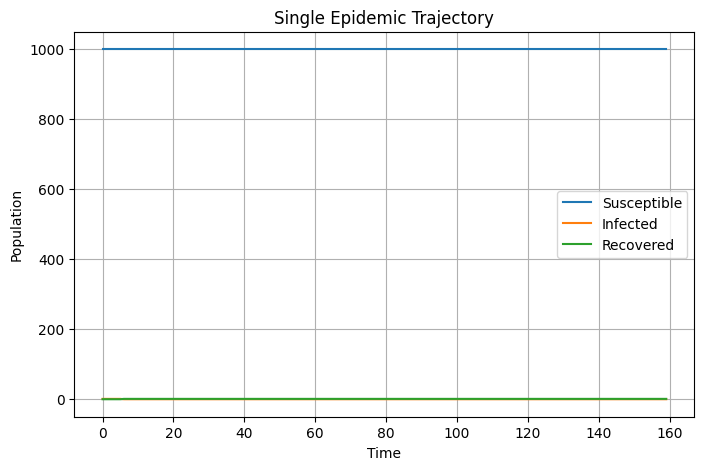

In [24]:
idx = 0

plt.figure(figsize=(8,5))

plt.plot(t, S[idx], label="Susceptible")
plt.plot(t, I[idx], label="Infected")
plt.plot(t, R[idx], label="Recovered")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Single Epidemic Trajectory")
plt.legend()
plt.grid(True)

plt.show()

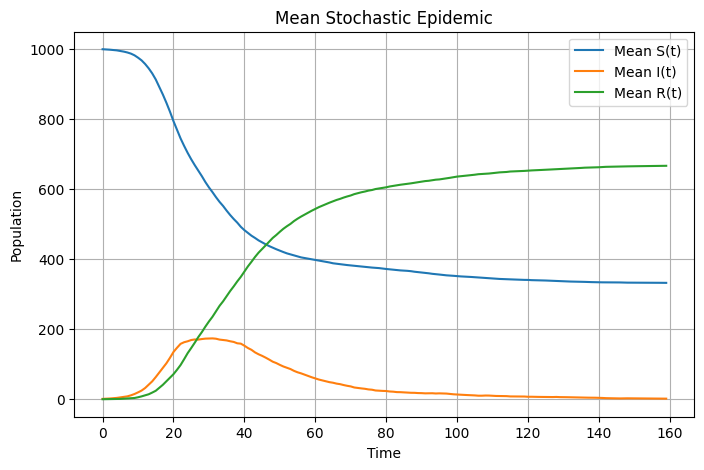

In [25]:
S_mean = S.mean(axis=0)
I_mean = I.mean(axis=0)
R_mean = R.mean(axis=0)

plt.figure(figsize=(8,5))

plt.plot(t, S_mean, label="Mean S(t)")
plt.plot(t, I_mean, label="Mean I(t)")
plt.plot(t, R_mean, label="Mean R(t)")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Mean Stochastic Epidemic")
plt.legend()
plt.grid(True)

plt.show()

In [26]:
model, t_tensor, y_tensor = train_model()

Epoch 0 | Loss 0.182811
Epoch 500 | Loss 0.063970
Epoch 1000 | Loss 0.063955
Epoch 1500 | Loss 0.063953
Epoch 2000 | Loss 0.063952
Epoch 2500 | Loss 0.063951


MSE: 0.06395118683576584
R2: 0.41426023840904236
Error plot saved


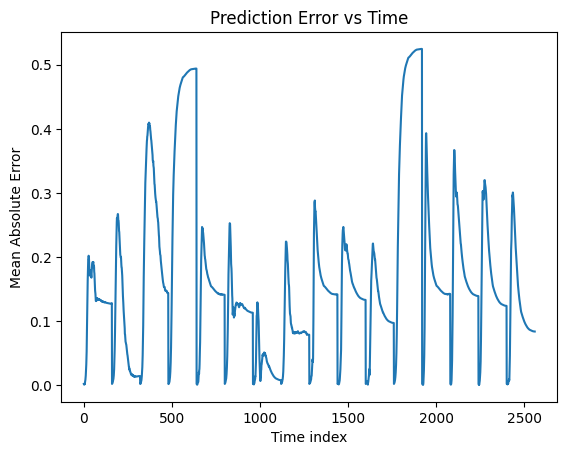

In [27]:
evaluate(model, t_tensor, y_tensor)

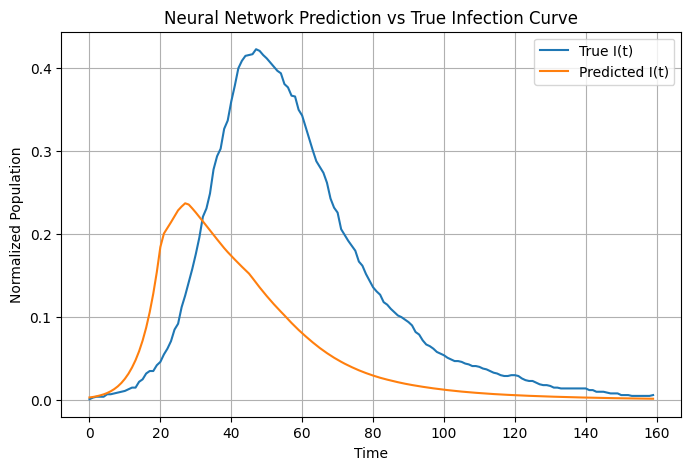

In [28]:
with torch.no_grad():
    pred = model(t_tensor).numpy()

y_true = y_tensor.numpy()

# plot only one epidemic trajectory
T = 160
idx = 0

true_curve = y_true[idx*T:(idx+1)*T]
pred_curve = pred[idx*T:(idx+1)*T]

plt.figure(figsize=(8,5))

plt.plot(true_curve[:,1], label="True I(t)")
plt.plot(pred_curve[:,1], label="Predicted I(t)")

plt.xlabel("Time")
plt.ylabel("Normalized Population")
plt.title("Neural Network Prediction vs True Infection Curve")

plt.legend()
plt.grid(True)

plt.show()

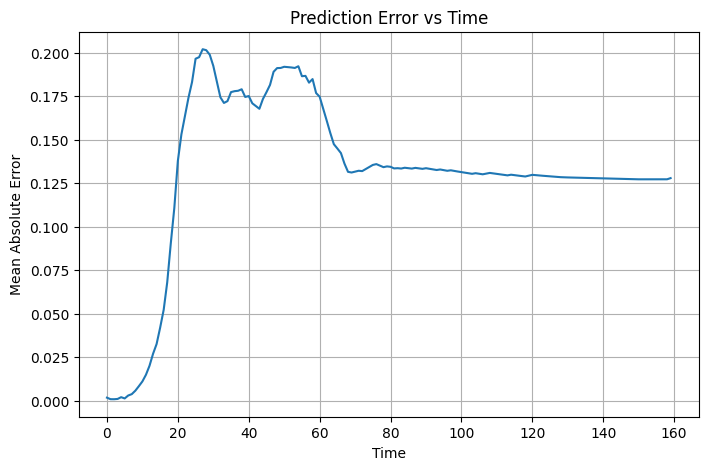

In [29]:
error = np.abs(y_true[:T] - pred[:T]).mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(error)

plt.xlabel("Time")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error vs Time")

plt.grid(True)

plt.show()

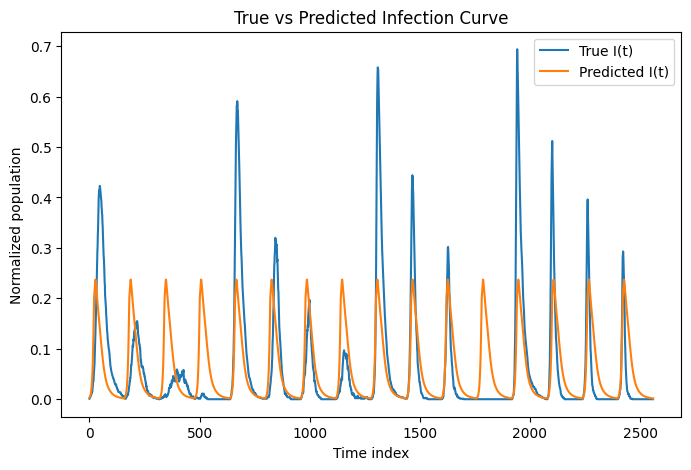

In [30]:
with torch.no_grad():
    pred = model(t_tensor).numpy()

y_true = y_tensor.numpy()

plt.figure(figsize=(8,5))

plt.plot(y_true[:,1], label="True I(t)")
plt.plot(pred[:,1], label="Predicted I(t)")

plt.title("True vs Predicted Infection Curve")
plt.xlabel("Time index")
plt.ylabel("Normalized population")
plt.legend()

plt.show()

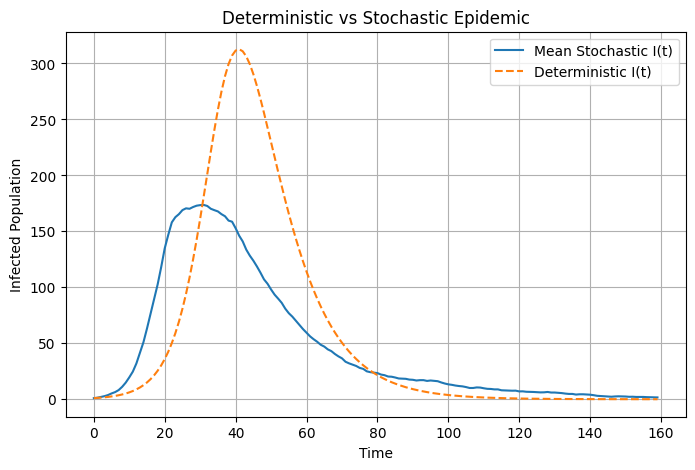

In [31]:
det = np.load("../results/deterministic_sir.npz")

S_det = det["S"]
I_det = det["I"]
R_det = det["R"]

plt.figure(figsize=(8,5))

plt.plot(t, I_mean, label="Mean Stochastic I(t)")
plt.plot(t, I_det, label="Deterministic I(t)", linestyle="--")

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("Deterministic vs Stochastic Epidemic")
plt.legend()
plt.grid(True)

plt.show()

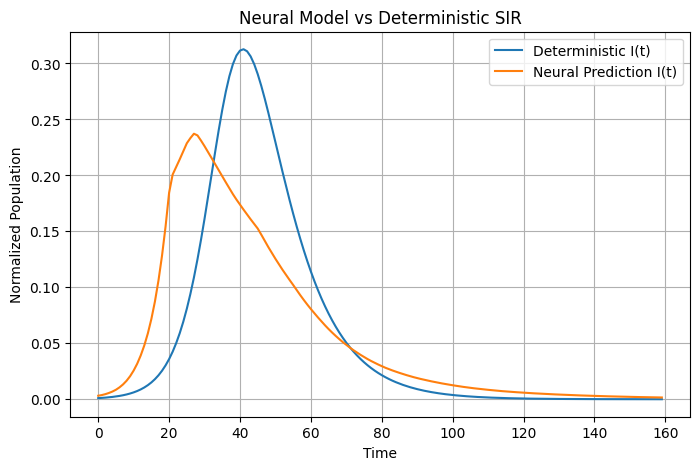

In [32]:
det = np.load("../results/deterministic_sir.npz")
I_det = det["I"]

plt.figure(figsize=(8,5))

plt.plot(t, I_det / 1000, label="Deterministic I(t)")
plt.plot(pred_curve[:,1], label="Neural Prediction I(t)")

plt.xlabel("Time")
plt.ylabel("Normalized Population")
plt.title("Neural Model vs Deterministic SIR")

plt.legend()
plt.grid(True)

plt.show()

### Model Evaluation

The neural network learns a smooth approximation of the epidemic trajectory
from stochastic simulation data.

Although the model does not perfectly reproduce the infection peak,
the overall temporal dynamics are captured.

This demonstrates that neural networks can learn epidemic evolution
from stochastic simulations, which can later be used for equation
discovery using symbolic regression methods such as PySINDy or PySR.